In [1]:
!pip install --upgrade wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 8.4 MB/s eta 0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.22.2
    Uninstalling wandb-0.22.2:
      Successfully uninstalled wandb-0.22.2


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import seaborn as sns
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPool2D, DepthwiseConv2D, Add,
    Dropout, Flatten, Dense, Activation, GlobalAveragePooling2D, Input, ReLU,
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from kaggle_secrets import UserSecretsClient

import wandb
from wandb.integration.keras import WandbMetricsLogger

2026-02-10 12:21:00.532974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770726060.895401      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770726061.004813      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770726061.855595      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770726061.855641      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770726061.855644      24 computation_placer.cc:177] computation placer alr

In [3]:
print(wandb.__version__)

0.24.2


In [4]:
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("garbage_classification_key")

os.environ["WANDB_API_KEY"] = api_key

wandb.init(project="garbage-classification-portfolio")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: suyeemon-digital (geni1) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.24.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260210_122118-kyrnbycq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dutiful-resonance-8
wandb: ⭐️ View project at https://wandb.ai/geni1/garbage-classification-portfolio
wandb: 🚀 View run at https://wandb.ai/geni1/garbage-classification-portfolio/runs/kyrnbycq


In [5]:
DATASET_DIR = Path("/kaggle/input/datasets/zlatan599/garbage-dataset-classification/Garbage_Dataset_Classification/images")
CLASSES = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])

print("Classes:", CLASSES)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
class_counts = {}

for cls_dir in DATASET_DIR.iterdir():
    if cls_dir.is_dir():
        class_counts[cls_dir.name] = len(list(cls_dir.glob("*")))

class_df = pd.DataFrame(list(class_counts.items()), columns=["class", "count"])
print(class_df)

       class  count
0      metal   2084
1      glass   2500
2      paper   2315
3      trash   2500
4  cardboard   2214
5    plastic   2288


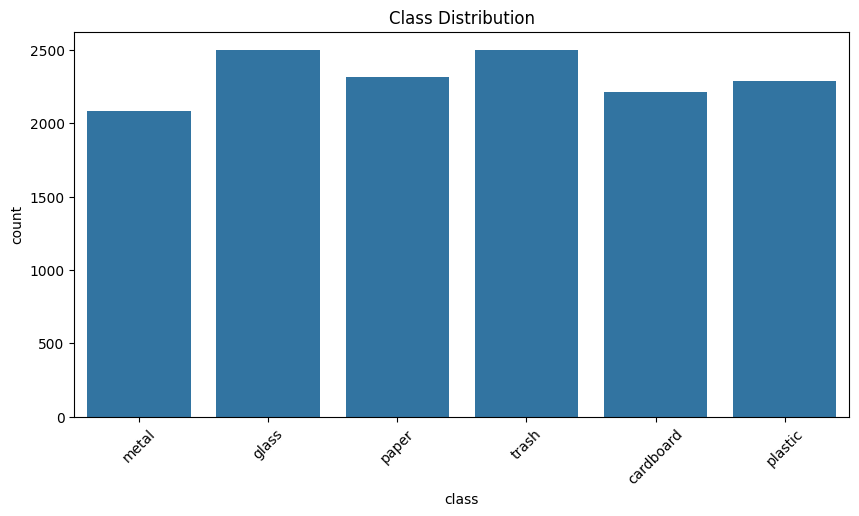

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(data=class_df, x="class", y="count")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [8]:
image_info = []

for cls_dir in DATASET_DIR.iterdir():
    if cls_dir.is_dir():
        for img_path in cls_dir.glob("*"):
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    image_info.append({
                        "class": cls_dir.name,
                        "width": width,
                        "height": height,
                        "aspect_ratio": width / height
                    })
            except:
                continue

img_df = pd.DataFrame(image_info)
print(img_df.describe())

         width   height  aspect_ratio
count  13901.0  13901.0       13901.0
mean     256.0    256.0           1.0
std        0.0      0.0           0.0
min      256.0    256.0           1.0
25%      256.0    256.0           1.0
50%      256.0    256.0           1.0
75%      256.0    256.0           1.0
max      256.0    256.0           1.0


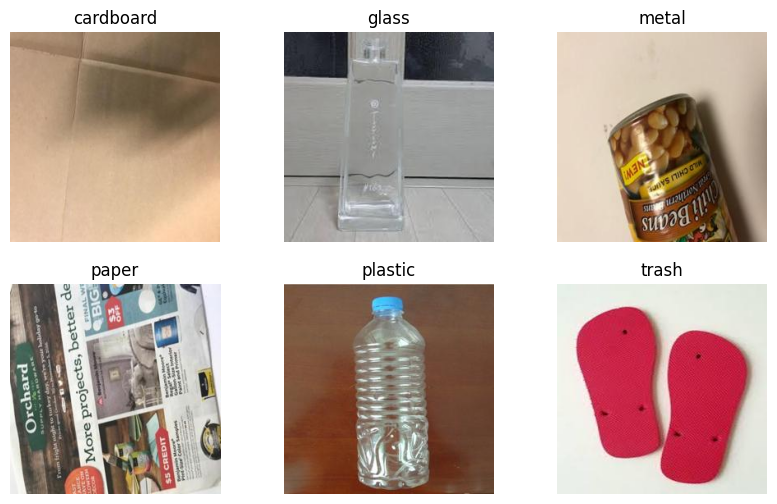

In [9]:
plt.figure(figsize=(10,6))
for i, cls in enumerate(CLASSES):
    img_path = next((DATASET_DIR / cls).glob("*"))
    img = Image.open(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.show()

In [10]:
img = Image.open(next(DATASET_DIR.rglob("*.jpg")))
img_array = np.array(img)
print("Image shape (H, W, C):", img_array.shape)

Image shape (H, W, C): (256, 256, 3)


In [11]:
DATA_DIR = DATASET_DIR

filepaths = []
labels = []

for cls in os.listdir(DATA_DIR):
    cls_path = os.path.join(DATA_DIR, cls)
    
    if os.path.isdir(cls_path):
        for img in os.listdir(cls_path):
            filepaths.append(os.path.join(cls_path, img))
            labels.append(cls)

df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

print("Total images:", len(df))

Total images: 13901


In [12]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["class"],
    random_state=42
)

In [13]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=1/3,
    stratify=temp_df["class"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 9730
Validation: 2780
Test: 1391


In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)


test_val_datagen = ImageDataGenerator(rescale=1./255)

In [15]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = test_val_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_val_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nTrain samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 9730 validated image filenames belonging to 6 classes.
Found 2780 validated image filenames belonging to 6 classes.
Found 1391 validated image filenames belonging to 6 classes.

Train samples: 9730
Validation samples: 2780
Test samples: 1391


In [16]:
num_classes = len(train_generator.class_indices)
print(train_generator.class_indices)
print("Number of classes:", num_classes)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Number of classes: 6


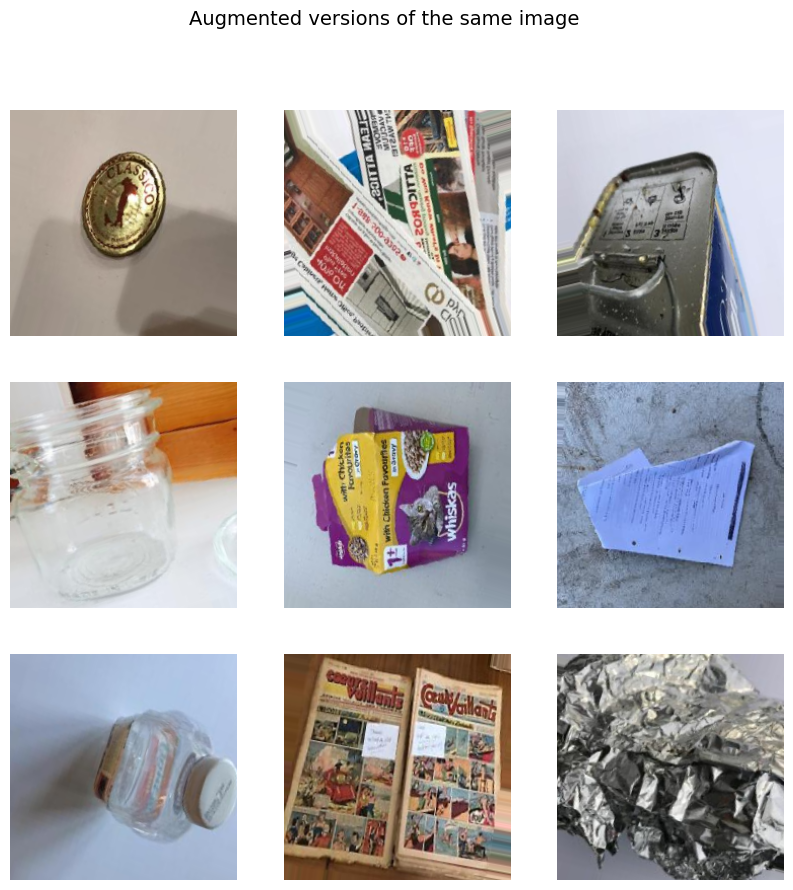

In [17]:
plt.figure(figsize=(10, 10))

for i in range(9):
    image, label = next(train_generator)
    plt.subplot(3, 3, i + 1)
    plt.imshow(image[0])
    plt.axis("off")

plt.suptitle("Augmented versions of the same image", fontsize=14)
plt.show()

In [18]:
results_df = pd.DataFrame(columns=[
    "Model",
    "Test Loss",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

## Baseline CNN Training

In [19]:
IMG_SHAPE = (224, 224, 3)

baseline_model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=IMG_SHAPE),
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.3),
    
    # Block 2
    Conv2D(128, (5,5), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.3),

    # Block 3
    Conv2D(512, (3,3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.3),

    # Block 4  (reduced from 512 → 256)
    Conv2D(512, (3,3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Head
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),

    Dense(6, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1770726218.368915      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770726218.375819      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## RESNET18 SCRATCH

In [20]:
def residual_block(x, filters, stride=1):

    shortcut = x

    # First Conv
    x = Conv2D(filters, (3,3), strides=stride, padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Second Conv
    x = Conv2D(filters, (3,3), strides=1, padding="same")(x)
    x = BatchNormalization()(x)

    # Match dimensions if needed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1,1), strides=stride, padding="same")(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Add skip connection
    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x


In [21]:
def build_resnet18(input_shape=(224,224,3), num_classes=6):

    inputs = Input(shape=input_shape)

    x = Conv2D(64,(7,7),strides=2,padding="same")(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPool2D((3,3),strides=2,padding="same")(x)

    x = residual_block(x,64)
    x = residual_block(x,64)

    x = residual_block(x,128,stride=2)
    x = residual_block(x,128)

    x = residual_block(x,256,stride=2)
    x = residual_block(x,256)

    x = residual_block(x,512,stride=2)
    x = residual_block(x,512)

    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes,activation="softmax")(x)

    return Model(inputs,outputs)

## MOBILENETV2 SCRATCH

In [22]:
def build_mobilenetv2_scratch(input_shape=(224,224,3), num_classes=6):

    print("\nBuilding MobileNetV2 From Scratch...")

    base_model = MobileNetV2(
        weights=None,              # FROM SCRATCH
        include_top=False,
        input_shape=input_shape
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(
        inputs=base_model.input,
        outputs=outputs,
        name="MobileNetV2_Scratch"
    )

    return model

## TRAIN + SUMMARY + PLOT FUNCTION

In [23]:
def train_evaluate_model(model, model_name):

    global results_df

    print("\nModel Summary:", model_name)
    model.summary()

    wandb.init(project="garbage-classification-portfolio",name=model_name)

    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    checkpoint = ModelCheckpoint(
        f"{model_name}_best.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=[
            WandbMetricsLogger(),
            checkpoint,
            ReduceLROnPlateau(monitor="val_loss",factor=0.3,patience=3)
        ]
    )

    # ⭐ Plot Loss
    plt.figure(figsize=(8,5))
    plt.plot(history.history["loss"],label="Train Loss")
    plt.plot(history.history["val_loss"],label="Val Loss")
    plt.title(model_name+" Loss Curve")
    plt.legend()
    plt.show()

    best_model = load_model(f"{model_name}_best.h5")

    test_loss,test_acc = best_model.evaluate(test_generator)

    test_generator.reset()
    y_true = test_generator.classes
    y_pred = np.argmax(best_model.predict(test_generator),axis=1)

    precision = precision_score(y_true,y_pred,average="macro")
    recall = recall_score(y_true,y_pred,average="macro")
    f1 = f1_score(y_true,y_pred,average="macro")

    print(classification_report(y_true,y_pred))

    results_df.loc[len(results_df)] = [
        model_name,test_loss,test_acc,precision,recall,f1
    ]

    wandb.finish()

    return best_model



Model Summary: Baseline_CNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,58

 Total params: 3,448,390 (13.15 MB)

 Trainable params: 3,444,422 (13.14 MB)

...

305/305 ━━━━━━━━━━━━━━━━━━━━ 139s 455ms/step - accuracy: 0.8277 - loss: 0.8495 - val_accuracy: 0.8022 - val_loss: 0.9835 - learning_rate: 3.0000e-05
Epoch 43/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8467 - loss: 0.8140
Epoch 43: val_loss did not improve from 0.98351
305/305 ━━━━━━━━━━━━━━━━━━━━ 137s 450ms/step - accuracy: 0.8466 - loss: 0.8140 - val_accuracy: 0.7518 - val_loss: 1.1377 - learning_rate: 3.0000e-05
Epoch 44/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8378 - loss: 0.8044
Epoch 44: val_loss did not improve from 0.98351
305/305 ━━━━━━━━━━━━━━━━━━━━ 137s 450ms/step - accuracy: 0.8378 - loss: 0.8045 - val_accuracy: 0.7860 - val_loss: 1.0088 - learning_rate: 3.0000e-05
Epoch 45/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8474 - loss: 0.7906
Epoch 45: val_loss did not improve from 0.98351
305/305 ━━━━━━━━━━━━━━━━━━━━ 136s 446ms/step - accuracy: 0.8474 - loss: 0.7906 - val_accuracy: 0.7950 - val_loss: 0.9899 - learning_rate: 3.00

305/305 ━━━━━━━━━━━━━━━━━━━━ 139s 455ms/step - accuracy: 0.8635 - loss: 0.7380 - val_accuracy: 0.8097 - val_loss: 0.9782 - learning_rate: 9.0000e-06
Epoch 47/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8675 - loss: 0.7166
Epoch 47: val_loss improved from 0.97823 to 0.95280, saving model to Baseline_CNN_best.h5


305/305 ━━━━━━━━━━━━━━━━━━━━ 137s 450ms/step - accuracy: 0.8675 - loss: 0.7166 - val_accuracy: 0.8108 - val_loss: 0.9528 - learning_rate: 9.0000e-06
Epoch 48/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.8651 - loss: 0.7207
Epoch 48: val_loss improved from 0.95280 to 0.92485, saving model to Baseline_CNN_best.h5


305/305 ━━━━━━━━━━━━━━━━━━━━ 137s 449ms/step - accuracy: 0.8651 - loss: 0.7207 - val_accuracy: 0.8147 - val_loss: 0.9249 - learning_rate: 9.0000e-06
Epoch 49/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8780 - loss: 0.6906
Epoch 49: val_loss improved from 0.92485 to 0.89737, saving model to Baseline_CNN_best.h5


305/305 ━━━━━━━━━━━━━━━━━━━━ 136s 444ms/step - accuracy: 0.8780 - loss: 0.6907 - val_accuracy: 0.8176 - val_loss: 0.8974 - learning_rate: 9.0000e-06
Epoch 50/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.8819 - loss: 0.6772
Epoch 50: val_loss did not improve from 0.89737
305/305 ━━━━━━━━━━━━━━━━━━━━ 136s 447ms/step - accuracy: 0.8819 - loss: 0.6772 - val_accuracy: 0.8000 - val_loss: 0.9627 - learning_rate: 9.0000e-06


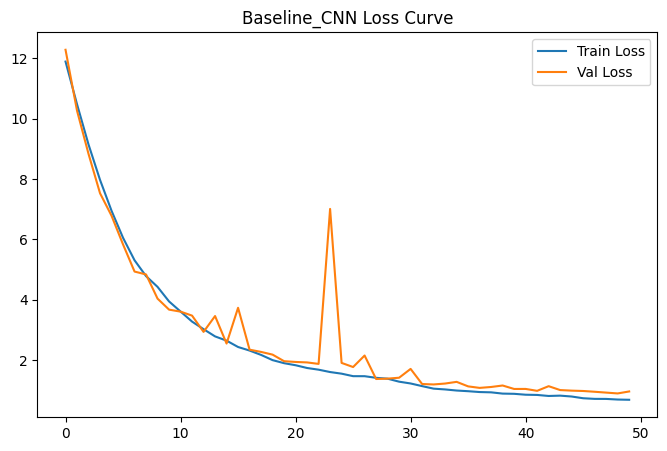

44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 256ms/step - accuracy: 0.8386 - loss: 0.8362
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       222
           1       0.86      0.81      0.83       250
           2       0.81      0.88      0.84       208
           3       0.85      0.82      0.83       232
           4       0.81      0.79      0.80       229
           5       0.83      0.81      0.82       250

    accuracy                           0.83      1391
   macro avg       0.83      0.83      0.83      1391
weighted avg       0.83      0.83      0.83      1391



wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:      epoch/accuracy ▁▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████
wandb:         epoch/epoch ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
wandb: epoch/learning_rate █████████████████████████▃▃▃▃▃▃▃▃▃▃▃▁▁▁▁
wandb:          epoch/loss █▇▆▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:  epoch/val_accuracy ▁▃▃▄▄▅▄▅▆▅▅▄▆▂▆▆▆▆▆▂▆▅▇▇▆▇▇▇▇▇▇███▇█████
wandb:      epoch/val_loss █▇▆▅▅▃▃▃▃▃▂▃▂▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:      epoch/accuracy 0.87616
wandb:         epoch/epoch 49
wandb: epoch/learning_rate 1e-05
wandb:          epoch/loss 0.68714
wandb:  epoch/val_accuracy 0.8
wandb:      epoch/val_loss 0.96269
wandb: 
wandb: 🚀 View run Baseline_CNN at: https://wandb.ai/geni1/garbage-classification-portfolio/runs/dz8hrr3p
wandb: ⭐️ View project at: https://wandb.ai/geni1/garbage-classification-portfolio
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wand

In [24]:
EPOCHS = 50

baseline_trained = train_evaluate_model(
    baseline_model,"Baseline_CNN"
)


Model Summary: ResNet18_Scratch


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │      9,472 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 56, 56,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 56, 56,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 56, 56,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_9[0][0]  

 Total params: 11,193,990 (42.70 MB)

 Trainable params: 11,184,390 (42.67 MB)

...

305/305 ━━━━━━━━━━━━━━━━━━━━ 130s 427ms/step - accuracy: 0.8284 - loss: 0.4825 - val_accuracy: 0.7831 - val_loss: 0.6408 - learning_rate: 3.0000e-05
Epoch 12/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8618 - loss: 0.4092
Epoch 12: val_loss did not improve from 0.64077
305/305 ━━━━━━━━━━━━━━━━━━━━ 129s 421ms/step - accuracy: 0.8618 - loss: 0.4092 - val_accuracy: 0.7820 - val_loss: 0.6466 - learning_rate: 3.0000e-05
Epoch 13/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8652 - loss: 0.3763
Epoch 13: val_loss did not improve from 0.64077
305/305 ━━━━━━━━━━━━━━━━━━━━ 127s 416ms/step - accuracy: 0.8652 - loss: 0.3764 - val_accuracy: 0.7817 - val_loss: 0.6472 - learning_rate: 3.0000e-05
Epoch 14/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8829 - loss: 0.3537
Epoch 14: val_loss improved from 0.64077 to 0.56648, saving model to ResNet18_Scratch_best.h5


305/305 ━━━━━━━━━━━━━━━━━━━━ 129s 423ms/step - accuracy: 0.8829 - loss: 0.3537 - val_accuracy: 0.8212 - val_loss: 0.5665 - learning_rate: 3.0000e-05
Epoch 15/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8894 - loss: 0.3159
Epoch 15: val_loss did not improve from 0.56648
305/305 ━━━━━━━━━━━━━━━━━━━━ 131s 428ms/step - accuracy: 0.8894 - loss: 0.3160 - val_accuracy: 0.8000 - val_loss: 0.6068 - learning_rate: 3.0000e-05
Epoch 16/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8896 - loss: 0.3117
Epoch 16: val_loss did not improve from 0.56648
305/305 ━━━━━━━━━━━━━━━━━━━━ 129s 422ms/step - accuracy: 0.8896 - loss: 0.3117 - val_accuracy: 0.7939 - val_loss: 0.6247 - learning_rate: 3.0000e-05
Epoch 17/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8949 - loss: 0.2892
Epoch 17: val_loss did not improve from 0.56648
305/305 ━━━━━━━━━━━━━━━━━━━━ 130s 426ms/step - accuracy: 0.8949 - loss: 0.2892 - val_accuracy: 0.8097 - val_loss: 0.5941 - learning_rate: 3.00

305/305 ━━━━━━━━━━━━━━━━━━━━ 130s 427ms/step - accuracy: 0.9255 - loss: 0.2330 - val_accuracy: 0.8453 - val_loss: 0.4844 - learning_rate: 9.0000e-06
Epoch 19/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9237 - loss: 0.2223
Epoch 19: val_loss did not improve from 0.48441
305/305 ━━━━━━━━━━━━━━━━━━━━ 131s 429ms/step - accuracy: 0.9237 - loss: 0.2223 - val_accuracy: 0.8381 - val_loss: 0.5366 - learning_rate: 9.0000e-06
Epoch 20/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9296 - loss: 0.2004
Epoch 20: val_loss did not improve from 0.48441
305/305 ━━━━━━━━━━━━━━━━━━━━ 129s 423ms/step - accuracy: 0.9296 - loss: 0.2004 - val_accuracy: 0.8396 - val_loss: 0.5077 - learning_rate: 9.0000e-06
Epoch 21/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9401 - loss: 0.1846
Epoch 21: val_loss did not improve from 0.48441
305/305 ━━━━━━━━━━━━━━━━━━━━ 129s 422ms/step - accuracy: 0.9401 - loss: 0.1846 - val_accuracy: 0.8439 - val_loss: 0.4859 - learning_rate: 9.00

305/305 ━━━━━━━━━━━━━━━━━━━━ 130s 426ms/step - accuracy: 0.9389 - loss: 0.1838 - val_accuracy: 0.8565 - val_loss: 0.4480 - learning_rate: 2.7000e-06
Epoch 23/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9457 - loss: 0.1656
Epoch 23: val_loss did not improve from 0.44801
305/305 ━━━━━━━━━━━━━━━━━━━━ 129s 422ms/step - accuracy: 0.9457 - loss: 0.1656 - val_accuracy: 0.8576 - val_loss: 0.4581 - learning_rate: 2.7000e-06
Epoch 24/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9416 - loss: 0.1773
Epoch 24: val_loss did not improve from 0.44801
305/305 ━━━━━━━━━━━━━━━━━━━━ 130s 425ms/step - accuracy: 0.9416 - loss: 0.1773 - val_accuracy: 0.8547 - val_loss: 0.4534 - learning_rate: 2.7000e-06
Epoch 25/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9465 - loss: 0.1619
Epoch 25: val_loss did not improve from 0.44801
305/305 ━━━━━━━━━━━━━━━━━━━━ 129s 424ms/step - accuracy: 0.9465 - loss: 0.1619 - val_accuracy: 0.8493 - val_loss: 0.4635 - learning_rate: 2.70

305/305 ━━━━━━━━━━━━━━━━━━━━ 130s 425ms/step - accuracy: 0.9523 - loss: 0.1524 - val_accuracy: 0.8604 - val_loss: 0.4479 - learning_rate: 2.4300e-07
Epoch 30/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9480 - loss: 0.1575
Epoch 30: val_loss did not improve from 0.44792
305/305 ━━━━━━━━━━━━━━━━━━━━ 133s 435ms/step - accuracy: 0.9481 - loss: 0.1575 - val_accuracy: 0.8608 - val_loss: 0.4512 - learning_rate: 2.4300e-07
Epoch 31/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9512 - loss: 0.1451
Epoch 31: val_loss did not improve from 0.44792
305/305 ━━━━━━━━━━━━━━━━━━━━ 134s 440ms/step - accuracy: 0.9512 - loss: 0.1451 - val_accuracy: 0.8601 - val_loss: 0.4523 - learning_rate: 2.4300e-07
Epoch 32/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9499 - loss: 0.1539
Epoch 32: val_loss did not improve from 0.44792
305/305 ━━━━━━━━━━━━━━━━━━━━ 136s 447ms/step - accuracy: 0.9499 - loss: 0.1539 - val_accuracy: 0.8590 - val_loss: 0.4540 - learning_rate: 7.29

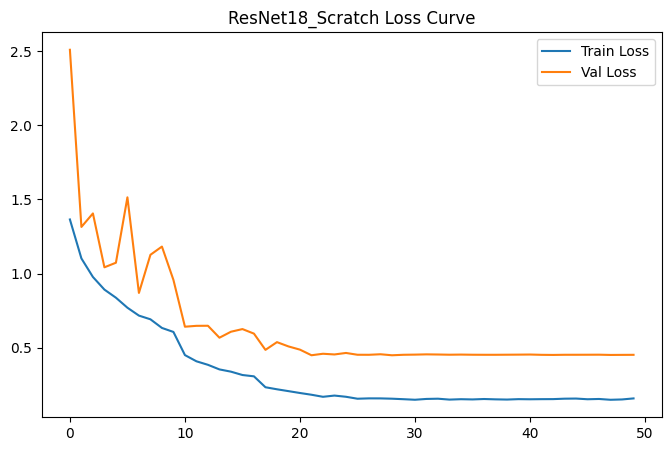

44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 205ms/step - accuracy: 0.8701 - loss: 0.4356
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step


wandb: updating run metadata


              precision    recall  f1-score   support

           0       0.88      0.91      0.89       222
           1       0.88      0.86      0.87       250
           2       0.83      0.89      0.86       208
           3       0.86      0.85      0.86       232
           4       0.85      0.84      0.84       229
           5       0.86      0.81      0.83       250

    accuracy                           0.86      1391
   macro avg       0.86      0.86      0.86      1391
weighted avg       0.86      0.86      0.86      1391



wandb: 
wandb: Run history:
wandb:      epoch/accuracy ▁▃▃▄▄▅▅▅▅▆▇▇▇▇██████████████████████████
wandb:         epoch/epoch ▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
wandb: epoch/learning_rate ████████▃▃▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          epoch/loss █▆▆▅▅▄▄▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:  epoch/val_accuracy ▁▄▄▅▆▆▆▅▆▇▇█▇▇▇█████████████████████████
wandb:      epoch/val_loss █▄▃▃▅▃▃▃▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:      epoch/accuracy 0.94902
wandb:         epoch/epoch 49
wandb: epoch/learning_rate 0.0
wandb:          epoch/loss 0.15657
wandb:  epoch/val_accuracy 0.86151
wandb:      epoch/val_loss 0.45093
wandb: 
wandb: 🚀 View run ResNet18_Scratch at: https://wandb.ai/geni1/garbage-classification-portfolio/runs/47yvtk2n
wandb: ⭐️ View project at: https://wandb.ai/geni1/garbage-classification-portfolio
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260210_142024-4

In [25]:
resnet_trained = train_evaluate_model(
    build_resnet18(),"ResNet18_Scratch"
)


Building MobileNetV2 From Scratch...

Model Summary: MobileNetV2_Scratch


Model: "MobileNetV2_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,592,582 (9.89 MB)

 Trainable params: 2,555,910 (9.75 MB)

...

305/305 ━━━━━━━━━━━━━━━━━━━━ 128s 420ms/step - accuracy: 0.5545 - loss: 1.1943 - val_accuracy: 0.5694 - val_loss: 1.1509 - learning_rate: 2.1870e-08
Epoch 30/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5476 - loss: 1.1974
Epoch 30: val_loss improved from 1.15086 to 1.11150, saving model to MobileNetV2_Scratch_best.h5


305/305 ━━━━━━━━━━━━━━━━━━━━ 130s 425ms/step - accuracy: 0.5477 - loss: 1.1974 - val_accuracy: 0.5896 - val_loss: 1.1115 - learning_rate: 2.1870e-08
Epoch 31/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.5671 - loss: 1.1667
Epoch 31: val_loss improved from 1.11150 to 1.09170, saving model to MobileNetV2_Scratch_best.h5


305/305 ━━━━━━━━━━━━━━━━━━━━ 129s 421ms/step - accuracy: 0.5671 - loss: 1.1667 - val_accuracy: 0.5932 - val_loss: 1.0917 - learning_rate: 2.1870e-08
Epoch 32/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.5675 - loss: 1.1649
Epoch 32: val_loss improved from 1.09170 to 1.08289, saving model to MobileNetV2_Scratch_best.h5


305/305 ━━━━━━━━━━━━━━━━━━━━ 131s 428ms/step - accuracy: 0.5675 - loss: 1.1650 - val_accuracy: 0.5968 - val_loss: 1.0829 - learning_rate: 2.1870e-08
Epoch 33/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5469 - loss: 1.1873
Epoch 33: val_loss improved from 1.08289 to 1.08088, saving model to MobileNetV2_Scratch_best.h5


305/305 ━━━━━━━━━━━━━━━━━━━━ 130s 425ms/step - accuracy: 0.5469 - loss: 1.1872 - val_accuracy: 0.6018 - val_loss: 1.0809 - learning_rate: 2.1870e-08
Epoch 34/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5652 - loss: 1.1827
Epoch 34: val_loss did not improve from 1.08088
305/305 ━━━━━━━━━━━━━━━━━━━━ 130s 425ms/step - accuracy: 0.5652 - loss: 1.1827 - val_accuracy: 0.6029 - val_loss: 1.0809 - learning_rate: 2.1870e-08
Epoch 35/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.5627 - loss: 1.1716
Epoch 35: val_loss did not improve from 1.08088
305/305 ━━━━━━━━━━━━━━━━━━━━ 133s 435ms/step - accuracy: 0.5627 - loss: 1.1716 - val_accuracy: 0.6011 - val_loss: 1.0821 - learning_rate: 2.1870e-08
Epoch 36/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5451 - loss: 1.1907
Epoch 36: val_loss did not improve from 1.08088
305/305 ━━━━━━━━━━━━━━━━━━━━ 129s 421ms/step - accuracy: 0.5451 - loss: 1.1907 - val_accuracy: 0.6007 - val_loss: 1.0828 - learning_rate: 2.18

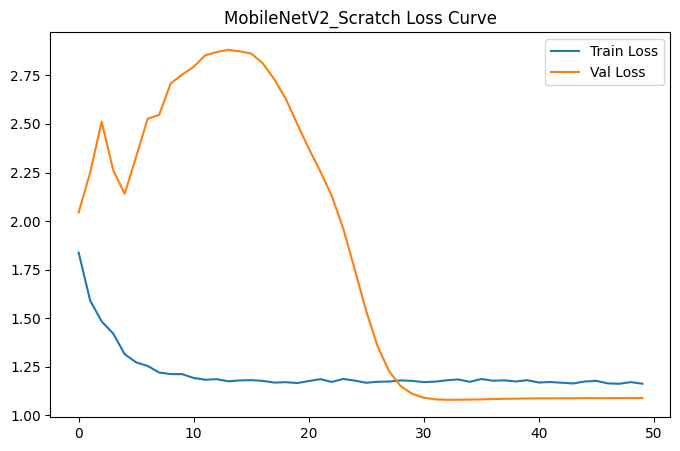

43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6114 - loss: 1.0419

2026-02-10 17:59:50.778673: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-10 17:59:50.915877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 343ms/step - accuracy: 0.6109 - loss: 1.0442
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 198ms/step


wandb: updating run metadata


              precision    recall  f1-score   support

           0       0.66      0.67      0.67       222
           1       0.65      0.64      0.65       250
           2       0.58      0.51      0.54       208
           3       0.57      0.62      0.59       232
           4       0.60      0.48      0.54       229
           5       0.55      0.66      0.60       250

    accuracy                           0.60      1391
   macro avg       0.60      0.60      0.60      1391
weighted avg       0.60      0.60      0.60      1391



wandb: 
wandb: Run history:
wandb:      epoch/accuracy ▁▃▄▅▆▇▇▇▇███████████████████████████████
wandb:         epoch/epoch ▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
wandb: epoch/learning_rate ████▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          epoch/loss █▅▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:  epoch/val_accuracy ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄▅▆▇█████████████████
wandb:      epoch/val_loss ▅▆▇▆▅▇▇▇██████▇▇▆▆▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:      epoch/accuracy 0.56906
wandb:         epoch/epoch 49
wandb: epoch/learning_rate 0.0
wandb:          epoch/loss 1.1635
wandb:  epoch/val_accuracy 0.59964
wandb:      epoch/val_loss 1.08977
wandb: 
wandb: 🚀 View run MobileNetV2_Scratch at: https://wandb.ai/geni1/garbage-classification-portfolio/runs/5qxxvqyd
wandb: ⭐️ View project at: https://wandb.ai/geni1/garbage-classification-portfolio
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260210_160937

In [26]:
mobilenet_trained = train_evaluate_model(
    build_mobilenetv2_scratch(),"MobileNetV2_Scratch"
)


In [27]:
display(results_df.sort_values(by="F1 Score",ascending=False))

,Model,Test Loss,Test Accuracy,Precision,Recall,F1 Score
1,ResNet18_Scratch,0.474938,0.859094,0.858772,0.860669,0.859372
0,Baseline_CNN,0.874672,0.826024,0.826036,0.827588,0.826162
2,MobileNetV2_Scratch,1.094600,0.600288,0.602331,0.597782,0.597680
